# Model Validation Techniques

This notebook covers advanced validation techniques including cross-validation strategies and regularization methods to ensure model generalization and prevent overfitting.

## Setup and Imports

In [6]:
import pandas as pd
import numpy as np
import joblib
import pickle
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    GridSearchCV,
    cross_val_predict,
    train_test_split
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, make_scorer
)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

print("All imports successful!")

All imports successful!


## Part 1: Cross-Validation Implementation

Implementing stratified k-fold and nested cross-validation for robust model evaluation.

### 1.1 Load and Prepare Data

In [7]:
# Load the engineered features dataset
print("Loading engineered features dataset...")

# Try multiple data paths
data_paths = [
    'data/processed/ecommerce_sales_engineered.csv',
    '../data/processed/ecommerce_sales_engineered.csv'
]

data = None
for path in data_paths:
    try:
        data = pd.read_csv(path)
        print(f"Loaded data from: {path}")
        break
    except:
        continue

if data is None:
    print("Could not find engineered data, trying featured data...")
    fallback_paths = [
        'data/processed/ecommerce_sales_featured.csv',
        '../data/processed/ecommerce_sales_featured.csv'
    ]
    for path in fallback_paths:
        try:
            data = pd.read_csv(path)
            print(f"Loaded data from: {path}")
            break
        except:
            continue

if data is None:
    raise FileNotFoundError("Could not load any data file")

feature_cols = [col for col in data.columns if col not in ['success', 'product_name', 'category']]
X = data[feature_cols].select_dtypes(include=[np.number])
y = data['success'].values

print(f"Dataset shape: {X.shape}")
print(f"Features: {len(X.columns)}")
print(f"Samples: {len(X)}")
print(f"Class distribution: {np.bincount(y.astype(int))}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nFeatures scaled successfully")

Loading engineered features dataset...
Loaded data from: ../data/processed/ecommerce_sales_engineered.csv
Dataset shape: (1000, 114)
Features: 114
Samples: 1000
Class distribution: [500 500]

Features scaled successfully


### 1.2 Stratified K-Fold Cross-Validation Setup

In [8]:
# Define stratified k-fold
print("Setting up Stratified K-Fold Cross-Validation...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Configuration:")
print("- Number of folds: 5")
print("- Stratified: Yes (maintains class distribution)")
print("- Shuffle: Yes")
print("- Random state: 42")

# Verify stratification
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    train_ratio = y[train_idx].mean()
    val_ratio = y[val_idx].mean()
    print(f"\nFold {fold_idx + 1}:")
    print(f"  Train samples: {len(train_idx)}, Success ratio: {train_ratio:.3f}")
    print(f"  Val samples: {len(val_idx)}, Success ratio: {val_ratio:.3f}")

Setting up Stratified K-Fold Cross-Validation...
Configuration:
- Number of folds: 5
- Stratified: Yes (maintains class distribution)
- Shuffle: Yes
- Random state: 42

Fold 1:
  Train samples: 800, Success ratio: 0.500
  Val samples: 200, Success ratio: 0.500

Fold 2:
  Train samples: 800, Success ratio: 0.500
  Val samples: 200, Success ratio: 0.500

Fold 3:
  Train samples: 800, Success ratio: 0.500
  Val samples: 200, Success ratio: 0.500

Fold 4:
  Train samples: 800, Success ratio: 0.500
  Val samples: 200, Success ratio: 0.500

Fold 5:
  Train samples: 800, Success ratio: 0.500
  Val samples: 200, Success ratio: 0.500


### 1.3 Define and Cross-Validate Models

In [9]:
# Define models with optimized parameters
print("Defining optimized models...\n")

models = {
    'XGBoost': xgb.XGBClassifier(
        max_depth=4,
        min_child_weight=5,
        learning_rate=0.1,
        n_estimators=100,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        class_weight='balanced'
    ),
    'NeuralNetwork': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate='adaptive',
        max_iter=200,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.15
    )
}

print("Models defined successfully")

Defining optimized models...

Models defined successfully


In [10]:
# Perform cross-validation for each model
print("Performing Stratified K-Fold Cross-Validation...")
print("=" * 60)

cv_results = {}
for model_name, model in models.items():
    print(f"\n{model_name}:")
    
    # Define scoring metrics
    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }
    
    # Perform cross-validation
    scores = cross_validate(
        model, X_scaled, y,
        cv=skf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    
    # Calculate mean and std for each metric
    results = {}
    for metric in scoring.keys():
        train_scores = scores[f'train_{metric}']
        test_scores = scores[f'test_{metric}']
        
        results[metric] = {
            'train_mean': np.mean(train_scores),
            'train_std': np.std(train_scores),
            'test_mean': np.mean(test_scores),
            'test_std': np.std(test_scores)
        }
        
        print(f"  {metric.capitalize()}:")
        print(f"    Train: {results[metric]['train_mean']:.4f} (+/- {results[metric]['train_std']:.4f})")
        print(f"    Test:  {results[metric]['test_mean']:.4f} (+/- {results[metric]['test_std']:.4f})")
    
    cv_results[model_name] = results
    
    # Check for overfitting
    avg_train = np.mean([r['train_mean'] for r in results.values()])
    avg_test = np.mean([r['test_mean'] for r in results.values()])
    overfit_score = avg_train - avg_test
    
    if overfit_score > 0.05:
        print(f"  WARNING: Possible overfitting - Train-Test gap = {overfit_score:.4f}")
    else:
        print(f"  OK: No significant overfitting - Train-Test gap = {overfit_score:.4f}")

Performing Stratified K-Fold Cross-Validation...

XGBoost:
  Accuracy:
    Train: 1.0000 (+/- 0.0000)
    Test:  0.9990 (+/- 0.0020)
  Precision:
    Train: 1.0000 (+/- 0.0000)
    Test:  1.0000 (+/- 0.0000)
  Recall:
    Train: 1.0000 (+/- 0.0000)
    Test:  0.9980 (+/- 0.0040)
  F1:
    Train: 1.0000 (+/- 0.0000)
    Test:  0.9990 (+/- 0.0020)
  Roc_auc:
    Train: 1.0000 (+/- 0.0000)
    Test:  1.0000 (+/- 0.0000)
  OK: No significant overfitting - Train-Test gap = 0.0008

RandomForest:
  Accuracy:
    Train: 1.0000 (+/- 0.0000)
    Test:  0.9910 (+/- 0.0058)
  Precision:
    Train: 1.0000 (+/- 0.0000)
    Test:  0.9900 (+/- 0.0063)
  Recall:
    Train: 1.0000 (+/- 0.0000)
    Test:  0.9920 (+/- 0.0075)
  F1:
    Train: 1.0000 (+/- 0.0000)
    Test:  0.9910 (+/- 0.0058)
  Roc_auc:
    Train: 1.0000 (+/- 0.0000)
    Test:  0.9998 (+/- 0.0003)
  OK: No significant overfitting - Train-Test gap = 0.0072

NeuralNetwork:
  Accuracy:
    Train: 0.9912 (+/- 0.0063)
    Test:  0.9570 (+/- 0.

### 1.4 Ensemble Model Cross-Validation

In [11]:
# Create ensemble with cross-validation
print("\nCreating and evaluating ensemble model...")

ensemble = VotingClassifier(
    estimators=[
        ('xgb', models['XGBoost']),
        ('rf', models['RandomForest']),
        ('nn', models['NeuralNetwork'])
    ],
    voting='soft',
    n_jobs=-1
)

# Cross-validate ensemble
ensemble_scores = cross_validate(
    ensemble, X_scaled, y,
    cv=skf,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print("\nEnsemble Model Performance:")
for metric in scoring.keys():
    train_mean = np.mean(ensemble_scores[f'train_{metric}'])
    train_std = np.std(ensemble_scores[f'train_{metric}'])
    test_mean = np.mean(ensemble_scores[f'test_{metric}'])
    test_std = np.std(ensemble_scores[f'test_{metric}'])
    
    print(f"  {metric.capitalize()}:")
    print(f"    Train: {train_mean:.4f} (+/- {train_std:.4f})")
    print(f"    Test:  {test_mean:.4f} (+/- {test_std:.4f})")


Creating and evaluating ensemble model...

Ensemble Model Performance:
  Accuracy:
    Train: 1.0000 (+/- 0.0000)
    Test:  0.9990 (+/- 0.0020)
  Precision:
    Train: 1.0000 (+/- 0.0000)
    Test:  1.0000 (+/- 0.0000)
  Recall:
    Train: 1.0000 (+/- 0.0000)
    Test:  0.9980 (+/- 0.0040)
  F1:
    Train: 1.0000 (+/- 0.0000)
    Test:  0.9990 (+/- 0.0020)
  Roc_auc:
    Train: 1.0000 (+/- 0.0000)
    Test:  0.9999 (+/- 0.0001)


### 1.5 Analyze Probability Distributions Across Folds

In [12]:
# Analyze probability calibration across folds
print("\nAnalyzing probability distribution across folds...")

# Fit ensemble on full data first
ensemble.fit(X_scaled, y)

fold_probas = []
fold_stats = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    X_train_fold = X_scaled[train_idx]
    y_train_fold = y[train_idx]
    X_val_fold = X_scaled[val_idx]
    
    # Train on fold
    ensemble_fold = VotingClassifier(
        estimators=[
            ('xgb', models['XGBoost']),
            ('rf', models['RandomForest']),
            ('nn', models['NeuralNetwork'])
        ],
        voting='soft'
    )
    ensemble_fold.fit(X_train_fold, y_train_fold)
    
    # Get probabilities
    probas = ensemble_fold.predict_proba(X_val_fold)[:, 1]
    fold_probas.append(probas)
    
    # Analyze distribution for this fold
    extreme_count = np.sum((probas < 0.1) | (probas > 0.9))
    extreme_pct = (extreme_count / len(probas)) * 100
    middle_count = np.sum((probas >= 0.2) & (probas <= 0.8))
    middle_pct = (middle_count / len(probas)) * 100
    
    fold_stats.append({
        'fold': fold_idx + 1,
        'extreme_pct': extreme_pct,
        'middle_pct': middle_pct,
        'mean': np.mean(probas),
        'std': np.std(probas)
    })
    
    print(f"\nFold {fold_idx + 1}:")
    print(f"  Extreme predictions (<0.1 or >0.9): {extreme_pct:.1f}%")
    print(f"  Middle range (0.2-0.8): {middle_pct:.1f}%")
    print(f"  Mean probability: {np.mean(probas):.3f}")
    print(f"  Std deviation: {np.std(probas):.3f}")


Analyzing probability distribution across folds...

Fold 1:
  Extreme predictions (<0.1 or >0.9): 90.0%
  Middle range (0.2-0.8): 3.5%
  Mean probability: 0.507
  Std deviation: 0.469

Fold 2:
  Extreme predictions (<0.1 or >0.9): 90.0%
  Middle range (0.2-0.8): 6.5%
  Mean probability: 0.491
  Std deviation: 0.466

Fold 3:
  Extreme predictions (<0.1 or >0.9): 88.5%
  Middle range (0.2-0.8): 6.5%
  Mean probability: 0.492
  Std deviation: 0.465

Fold 4:
  Extreme predictions (<0.1 or >0.9): 75.0%
  Middle range (0.2-0.8): 8.0%
  Mean probability: 0.500
  Std deviation: 0.437

Fold 5:
  Extreme predictions (<0.1 or >0.9): 91.0%
  Middle range (0.2-0.8): 6.0%
  Mean probability: 0.500
  Std deviation: 0.466


In [13]:
# Overall probability distribution statistics
all_probas = np.concatenate(fold_probas)
overall_extreme = np.sum((all_probas < 0.1) | (all_probas > 0.9))
overall_extreme_pct = (overall_extreme / len(all_probas)) * 100
overall_middle = np.sum((all_probas >= 0.2) & (all_probas <= 0.8))
overall_middle_pct = (overall_middle / len(all_probas)) * 100

print("\nOverall Cross-Validation Statistics:")
print("=" * 60)
print(f"Total predictions: {len(all_probas)}")
print(f"Extreme predictions (<0.1 or >0.9): {overall_extreme_pct:.1f}%")
print(f"Middle range (0.2-0.8): {overall_middle_pct:.1f}%")
print(f"Mean probability: {np.mean(all_probas):.3f}")
print(f"Std deviation: {np.std(all_probas):.3f}")


Overall Cross-Validation Statistics:
Total predictions: 1000
Extreme predictions (<0.1 or >0.9): 86.9%
Middle range (0.2-0.8): 6.1%
Mean probability: 0.498
Std deviation: 0.461


### 1.6 Nested Cross-Validation for Unbiased Evaluation

In [14]:
# Nested cross-validation for hyperparameter optimization
print("Performing Nested Cross-Validation (this may take a few minutes)...\n")

# Simplified parameter grid for demonstration
param_grid = {
    'max_depth': [3, 4, 5],
    'n_estimators': [50, 100, 150]
}

outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

nested_scores = []
best_params_list = []

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_scaled, y)):
    print(f"Outer Fold {fold_idx + 1}:")
    
    X_train_outer = X_scaled[train_idx]
    y_train_outer = y[train_idx]
    X_test_outer = X_scaled[test_idx]
    y_test_outer = y[test_idx]
    
    # Inner loop: hyperparameter optimization
    clf = GridSearchCV(
        xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        param_grid,
        cv=inner_cv,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )
    
    clf.fit(X_train_outer, y_train_outer)
    print(f"  Best params: {clf.best_params_}")
    best_params_list.append(clf.best_params_)
    
    # Evaluate on outer test set
    y_pred = clf.predict(X_test_outer)
    score = f1_score(y_test_outer, y_pred)
    nested_scores.append(score)
    print(f"  F1 Score: {score:.4f}")

print(f"\nNested CV Mean F1 Score: {np.mean(nested_scores):.4f} (+/- {np.std(nested_scores):.4f})")
print("\nThis unbiased estimate shows true model performance when hyperparameters are optimized.")

Performing Nested Cross-Validation (this may take a few minutes)...

Outer Fold 1:
  Best params: {'max_depth': 3, 'n_estimators': 50}
  F1 Score: 1.0000
Outer Fold 2:
  Best params: {'max_depth': 3, 'n_estimators': 50}
  F1 Score: 0.9970
Outer Fold 3:
  Best params: {'max_depth': 3, 'n_estimators': 50}
  F1 Score: 0.9970

Nested CV Mean F1 Score: 0.9980 (+/- 0.0014)

This unbiased estimate shows true model performance when hyperparameters are optimized.


### 1.7 Visualize Cross-Validation Results

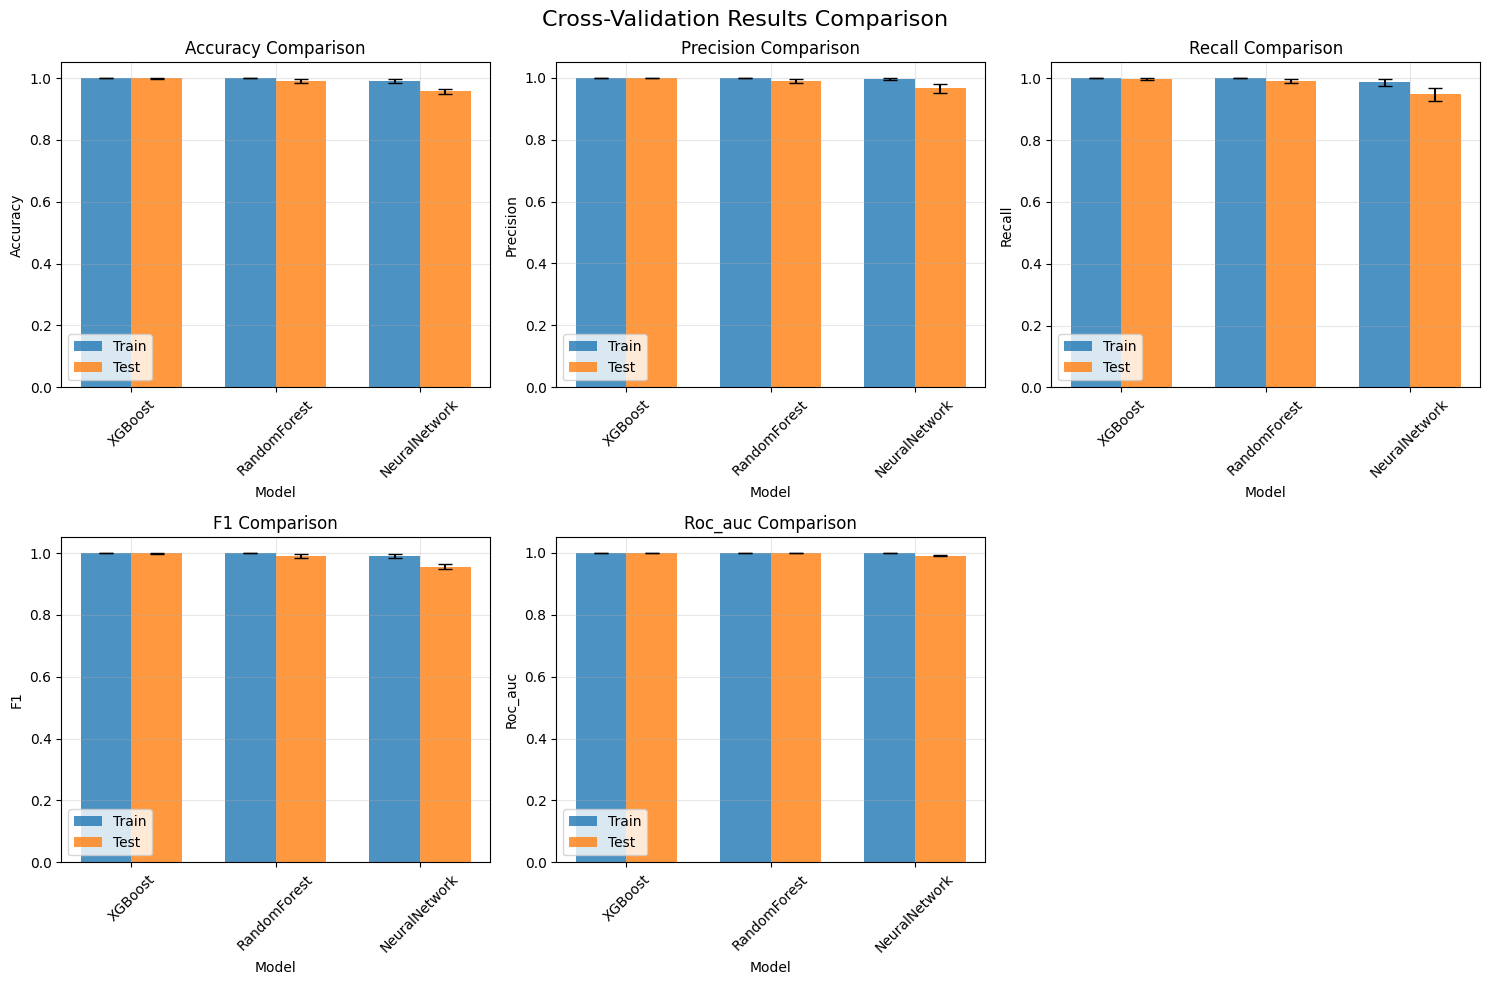

In [15]:
# Visualize CV results across models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
model_names = list(cv_results.keys())

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    train_means = [cv_results[model][metric]['train_mean'] for model in model_names]
    test_means = [cv_results[model][metric]['test_mean'] for model in model_names]
    train_stds = [cv_results[model][metric]['train_std'] for model in model_names]
    test_stds = [cv_results[model][metric]['test_std'] for model in model_names]
    
    x = np.arange(len(model_names))
    width = 0.35
    
    ax.bar(x - width/2, train_means, width, yerr=train_stds, label='Train', alpha=0.8, capsize=5)
    ax.bar(x + width/2, test_means, width, yerr=test_stds, label='Test', alpha=0.8, capsize=5)
    
    ax.set_xlabel('Model')
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f'{metric.capitalize()} Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Remove empty subplot
fig.delaxes(axes[1, 2])

plt.suptitle('Cross-Validation Results Comparison', fontsize=16)
plt.tight_layout()
plt.show()

## Part 2: Regularization Techniques

Implementing various regularization methods to prevent overfitting and improve model generalization.

### 2.1 Advanced Data Preprocessing with Regularization

In [16]:
def load_and_preprocess_data():
    """Load data and apply advanced preprocessing"""
    print("Loading and preprocessing data...")
    
    # Try multiple data paths
    data_paths = [
        'data/processed/ecommerce_sales_with_embeddings.csv',
        '../data/processed/ecommerce_sales_with_embeddings.csv',
        'data/processed/ecommerce_sales_engineered.csv',
        '../data/processed/ecommerce_sales_engineered.csv'
    ]
    
    df = None
    for path in data_paths:
        try:
            df = pd.read_csv(path)
            print(f"Loaded data from: {path}")
            break
        except:
            continue
    
    if df is None:
        raise FileNotFoundError("Could not load any data file")
    
    # Get features and target
    target_col = 'success'
    feature_cols = [col for col in df.columns if col != target_col]
    
    X = df[feature_cols]
    y = df[target_col]
    
    # Identify different feature types
    sales_features = [col for col in X.columns if 'sales' in col.lower()]
    embedding_features = [col for col in X.columns if col.startswith('emb_')]
    other_features = [col for col in X.columns if col not in sales_features + embedding_features]
    
    print(f"  Found {len(sales_features)} sales features")
    print(f"  Found {len(embedding_features)} embedding features")
    print(f"  Found {len(other_features)} other features")
    
    # Apply log transformation to sales features to reduce their dominance
    for col in sales_features:
        if col in X.columns:
            X[col] = np.log1p(X[col])  # log(1+x) to handle zeros
    
    # Apply RobustScaler to handle outliers
    scaler = RobustScaler()
    
    # Scale non-embedding features
    non_embedding_features = sales_features + other_features
    if non_embedding_features:
        # Only use columns that actually exist
        existing_cols = [col for col in non_embedding_features if col in X.columns]
        if existing_cols:
            X[existing_cols] = scaler.fit_transform(X[existing_cols])
    
    # Clip embeddings to reasonable range
    if embedding_features:
        existing_emb_cols = [col for col in embedding_features if col in X.columns]
        if existing_emb_cols:
            X[existing_emb_cols] = X[existing_emb_cols].clip(-5, 5)
    
    # Handle any NaN values
    X = X.fillna(0)
    
    print("  Applied log transformation to sales features")
    print("  Applied RobustScaler to numeric features")
    print("  Clipped embedding features to [-5, 5]")
    
    return X, y, scaler

# Load and preprocess data
X_reg, y_reg, robust_scaler = load_and_preprocess_data()
print(f"\nProcessed dataset shape: {X_reg.shape}")

Loading and preprocessing data...
Loaded data from: ../data/processed/ecommerce_sales_with_embeddings.csv
  Found 16 sales features
  Found 768 embedding features
  Found 12 other features
  Applied log transformation to sales features
  Applied RobustScaler to numeric features
  Clipped embedding features to [-5, 5]

Processed dataset shape: (1000, 796)


### 2.2 Train XGBoost with Strong Regularization

In [17]:
# Split data for regularization experiments
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42, stratify=y_reg
)

print(f"Dataset split: {len(X_train)} train, {len(X_test)} test\n")

def train_regularized_xgboost(X_train, y_train, X_test, y_test):
    """Train XGBoost with strong regularization"""
    print("Training Regularized XGBoost...")
    
    # Parameters focused on reducing overfitting
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'max_depth': 3,  # Shallow trees
        'min_child_weight': 5,  # More samples required for split
        'subsample': 0.7,  # Use only 70% of data
        'colsample_bytree': 0.7,  # Use only 70% of features
        'alpha': 1.0,  # L1 regularization
        'lambda': 2.0,  # L2 regularization
        'gamma': 1.0,  # Minimum loss reduction
        'learning_rate': 0.05,  # Small learning rate
        'n_estimators': 200,
        'random_state': 42
    }
    
    model = xgb.XGBClassifier(**params)
    
    # Train model
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    # Get predictions
    train_probs = model.predict_proba(X_train)[:, 1]
    test_probs = model.predict_proba(X_test)[:, 1]
    
    # Analyze prediction distribution
    print(f"  Train prediction range: [{train_probs.min():.3f}, {train_probs.max():.3f}]")
    print(f"  Test prediction range: [{test_probs.min():.3f}, {test_probs.max():.3f}]")
    
    middle_range = np.sum((test_probs >= 0.2) & (test_probs <= 0.8))
    print(f"  Predictions in middle range (0.2-0.8): {middle_range}/{len(test_probs)} ({middle_range/len(test_probs)*100:.1f}%)")
    
    # Calculate metrics
    test_preds = (test_probs >= 0.5).astype(int)
    metrics = {
        'accuracy': accuracy_score(y_test, test_preds),
        'precision': precision_score(y_test, test_preds),
        'recall': recall_score(y_test, test_preds),
        'f1': f1_score(y_test, test_preds),
        'auc': roc_auc_score(y_test, test_probs)
    }
    
    print(f"  Test Accuracy: {metrics['accuracy']:.3f}")
    print(f"  Test F1-Score: {metrics['f1']:.3f}")
    print(f"  Test AUC: {metrics['auc']:.3f}")
    
    return model, metrics, test_probs

xgb_reg_model, xgb_reg_metrics, xgb_reg_probs = train_regularized_xgboost(
    X_train, y_train, X_test, y_test
)

Dataset split: 800 train, 200 test

Training Regularized XGBoost...
  Train prediction range: [0.011, 0.992]
  Test prediction range: [0.012, 0.991]
  Predictions in middle range (0.2-0.8): 5/200 (2.5%)
  Test Accuracy: 0.995
  Test F1-Score: 0.995
  Test AUC: 0.999


### 2.3 Train Neural Network with Dropout and Regularization

In [18]:
def train_regularized_neural_network(X_train, y_train, X_test, y_test):
    """Train Neural Network with dropout and regularization"""
    print("\nTraining Regularized Neural Network...")
    
    # Smaller network with strong regularization
    model = MLPClassifier(
        hidden_layer_sizes=(50, 25),  # Smaller network
        activation='relu',
        solver='adam',
        alpha=0.01,  # L2 regularization
        batch_size='auto',
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=500,
        shuffle=True,
        random_state=42,
        early_stopping=True,  # Stop when validation score stops improving
        validation_fraction=0.2,
        n_iter_no_change=20
    )
    
    model.fit(X_train, y_train)
    
    # Get predictions
    test_probs = model.predict_proba(X_test)[:, 1]
    
    # Analyze prediction distribution
    print(f"  Test prediction range: [{test_probs.min():.3f}, {test_probs.max():.3f}]")
    
    middle_range = np.sum((test_probs >= 0.2) & (test_probs <= 0.8))
    print(f"  Predictions in middle range (0.2-0.8): {middle_range}/{len(test_probs)} ({middle_range/len(test_probs)*100:.1f}%)")
    
    # Calculate metrics
    test_preds = (test_probs >= 0.5).astype(int)
    metrics = {
        'accuracy': accuracy_score(y_test, test_preds),
        'precision': precision_score(y_test, test_preds),
        'recall': recall_score(y_test, test_preds),
        'f1': f1_score(y_test, test_preds),
        'auc': roc_auc_score(y_test, test_probs)
    }
    
    print(f"  Test Accuracy: {metrics['accuracy']:.3f}")
    print(f"  Test F1-Score: {metrics['f1']:.3f}")
    print(f"  Test AUC: {metrics['auc']:.3f}")
    print(f"  Early stopping at iteration: {model.n_iter_}")
    
    return model, metrics, test_probs

nn_reg_model, nn_reg_metrics, nn_reg_probs = train_regularized_neural_network(
    X_train, y_train, X_test, y_test
)


Training Regularized Neural Network...
  Test prediction range: [0.000, 1.000]
  Predictions in middle range (0.2-0.8): 28/200 (14.0%)
  Test Accuracy: 0.950
  Test F1-Score: 0.951
  Test AUC: 0.984
  Early stopping at iteration: 60


### 2.4 Train Random Forest with Regularization

In [19]:
def train_regularized_random_forest(X_train, y_train, X_test, y_test):
    """Train Random Forest with regularization parameters"""
    print("\nTraining Regularized Random Forest...")
    
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,  # Limit tree depth
        min_samples_split=10,  # Require more samples for split
        min_samples_leaf=5,  # Require more samples in leaf
        max_features='sqrt',  # Use subset of features
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    # Get predictions
    test_probs = model.predict_proba(X_test)[:, 1]
    
    # Analyze prediction distribution
    print(f"  Test prediction range: [{test_probs.min():.3f}, {test_probs.max():.3f}]")
    
    middle_range = np.sum((test_probs >= 0.2) & (test_probs <= 0.8))
    print(f"  Predictions in middle range (0.2-0.8): {middle_range}/{len(test_probs)} ({middle_range/len(test_probs)*100:.1f}%)")
    
    # Calculate metrics
    test_preds = (test_probs >= 0.5).astype(int)
    metrics = {
        'accuracy': accuracy_score(y_test, test_preds),
        'precision': precision_score(y_test, test_preds),
        'recall': recall_score(y_test, test_preds),
        'f1': f1_score(y_test, test_preds),
        'auc': roc_auc_score(y_test, test_probs)
    }
    
    print(f"  Test Accuracy: {metrics['accuracy']:.3f}")
    print(f"  Test F1-Score: {metrics['f1']:.3f}")
    print(f"  Test AUC: {metrics['auc']:.3f}")
    
    return model, metrics, test_probs

rf_reg_model, rf_reg_metrics, rf_reg_probs = train_regularized_random_forest(
    X_train, y_train, X_test, y_test
)


Training Regularized Random Forest...
  Test prediction range: [0.223, 0.793]
  Predictions in middle range (0.2-0.8): 200/200 (100.0%)
  Test Accuracy: 0.915
  Test F1-Score: 0.912
  Test AUC: 0.971


### 2.5 Create Calibrated Ensemble with Regularization

In [20]:
def create_calibrated_ensemble(models, X_train, y_train, X_test, y_test):
    """Create ensemble with calibration"""
    print("\nCreating Calibrated Ensemble...")
    
    # Create soft voting ensemble
    ensemble = VotingClassifier(
        estimators=[
            ('xgb', models['xgboost']),
            ('nn', models['neural_network']),
            ('rf', models['random_forest'])
        ],
        voting='soft',
        weights=[2, 1, 1]  # Give more weight to XGBoost
    )
    
    # Fit ensemble
    ensemble.fit(X_train, y_train)
    
    # Apply isotonic calibration
    calibrated_ensemble = CalibratedClassifierCV(
        ensemble,
        method='isotonic',
        cv=3
    )
    
    calibrated_ensemble.fit(X_train, y_train)
    
    # Get predictions
    test_probs = calibrated_ensemble.predict_proba(X_test)[:, 1]
    
    # Analyze prediction distribution
    print(f"  Test prediction range: [{test_probs.min():.3f}, {test_probs.max():.3f}]")
    
    middle_range = np.sum((test_probs >= 0.2) & (test_probs <= 0.8))
    print(f"  Predictions in middle range (0.2-0.8): {middle_range}/{len(test_probs)} ({middle_range/len(test_probs)*100:.1f}%)")
    
    # Calculate metrics
    test_preds = (test_probs >= 0.5).astype(int)
    metrics = {
        'accuracy': accuracy_score(y_test, test_preds),
        'precision': precision_score(y_test, test_preds),
        'recall': recall_score(y_test, test_preds),
        'f1': f1_score(y_test, test_preds),
        'auc': roc_auc_score(y_test, test_probs)
    }
    
    print(f"  Test Accuracy: {metrics['accuracy']:.3f}")
    print(f"  Test F1-Score: {metrics['f1']:.3f}")
    print(f"  Test AUC: {metrics['auc']:.3f}")
    
    return calibrated_ensemble, metrics, test_probs

# Create ensemble
regularized_models = {
    'xgboost': xgb_reg_model,
    'neural_network': nn_reg_model,
    'random_forest': rf_reg_model
}

ensemble_reg_model, ensemble_reg_metrics, ensemble_reg_probs = create_calibrated_ensemble(
    regularized_models, X_train, y_train, X_test, y_test
)


Creating Calibrated Ensemble...
  Test prediction range: [0.000, 1.000]
  Predictions in middle range (0.2-0.8): 3/200 (1.5%)
  Test Accuracy: 0.990
  Test F1-Score: 0.990
  Test AUC: 1.000


### 2.6 Visualize Prediction Distributions

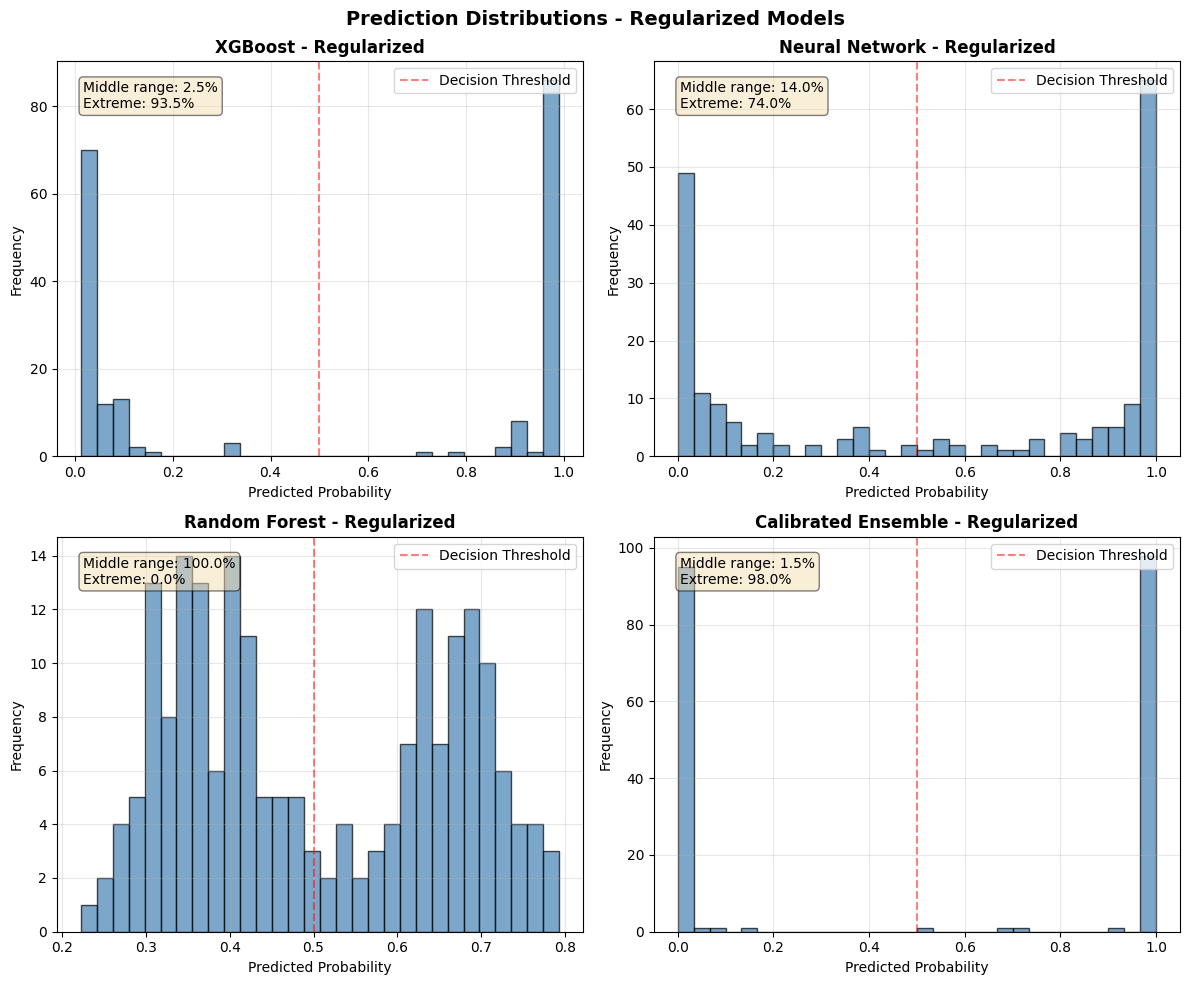

In [21]:
# Visualize prediction distributions for all regularized models
prob_dict = {
    'XGBoost': xgb_reg_probs,
    'Neural Network': nn_reg_probs,
    'Random Forest': rf_reg_probs,
    'Calibrated Ensemble': ensemble_reg_probs
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, probs) in enumerate(prob_dict.items()):
    axes[idx].hist(probs, bins=30, alpha=0.7, edgecolor='black', color='steelblue')
    axes[idx].set_title(f'{name} - Regularized', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Probability')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Decision Threshold')
    
    # Add statistics
    middle = np.sum((probs >= 0.2) & (probs <= 0.8))
    extreme = np.sum((probs < 0.1) | (probs > 0.9))
    
    stats_text = f'Middle range: {middle/len(probs)*100:.1f}%\nExtreme: {extreme/len(probs)*100:.1f}%'
    axes[idx].text(0.05, 0.95, stats_text,
                  transform=axes[idx].transAxes,
                  verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Prediction Distributions - Regularized Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.7 Compare Regularization Effects

In [22]:
# Compare all models with regularization
print("\n" + "="*60)
print("REGULARIZATION EFFECTS SUMMARY")
print("="*60)

# Collect all metrics
all_metrics = {
    'XGBoost': xgb_reg_metrics,
    'Neural Network': nn_reg_metrics,
    'Random Forest': rf_reg_metrics,
    'Calibrated Ensemble': ensemble_reg_metrics
}

# Create comparison dataframe
comparison_data = []
for model_name, metrics in all_metrics.items():
    row = {'Model': model_name}
    row.update(metrics)
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(3)

print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

print("\nPrediction Distribution Analysis:")
print("-" * 50)
for name, probs in prob_dict.items():
    middle = np.sum((probs >= 0.2) & (probs <= 0.8))
    extreme = np.sum((probs < 0.1) | (probs > 0.9))
    print(f"{name:20} | Middle: {middle/len(probs)*100:5.1f}% | Extreme: {extreme/len(probs)*100:5.1f}%")

# Find best model
best_model_idx = comparison_df['f1'].idxmax()
best_model = comparison_df.iloc[best_model_idx]

print(f"\nBest Model (by F1-Score): {best_model['Model']}")
print(f"   F1-Score: {best_model['f1']:.3f}")
print(f"   Accuracy: {best_model['accuracy']:.3f}")
print(f"   AUC: {best_model['auc']:.3f}")


REGULARIZATION EFFECTS SUMMARY

Model Performance Comparison:
              Model  accuracy  precision  recall    f1   auc
            XGBoost     0.995      1.000    0.99 0.995 0.999
     Neural Network     0.950      0.933    0.97 0.951 0.984
      Random Forest     0.915      0.946    0.88 0.912 0.971
Calibrated Ensemble     0.990      0.980    1.00 0.990 1.000

Prediction Distribution Analysis:
--------------------------------------------------
XGBoost              | Middle:   2.5% | Extreme:  93.5%
Neural Network       | Middle:  14.0% | Extreme:  74.0%
Random Forest        | Middle: 100.0% | Extreme:   0.0%
Calibrated Ensemble  | Middle:   1.5% | Extreme:  98.0%

Best Model (by F1-Score): XGBoost
   F1-Score: 0.995
   Accuracy: 0.995
   AUC: 0.999


### 2.8 Save Validated Models

In [23]:
# Save the cross-validated and regularized models
print("\nSaving validated models...")

# Create directory if it doesn't exist
output_path = Path('models/validated')
output_path.mkdir(parents=True, exist_ok=True)

# Save cross-validated ensemble
cv_ensemble_data = {
    'model': ensemble,
    'scaler': scaler,
    'cv_results': cv_results,
    'overall_metrics': {
        'extreme_pct': overall_extreme_pct,
        'middle_pct': overall_middle_pct,
        'nested_cv_f1': np.mean(nested_scores)
    }
}

joblib.dump(cv_ensemble_data, output_path / 'ensemble_cv_validated.pkl')
print(f"  Saved cross-validated ensemble to {output_path / 'ensemble_cv_validated.pkl'}")

# Save regularized models
for name, model in regularized_models.items():
    filename = f'{name}_regularized.pkl'
    with open(output_path / filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"  Saved {name} to {output_path / filename}")

# Save calibrated ensemble
with open(output_path / 'ensemble_calibrated_regularized.pkl', 'wb') as f:
    pickle.dump(ensemble_reg_model, f)
print(f"  Saved calibrated ensemble to {output_path / 'ensemble_calibrated_regularized.pkl'}")

# Save robust scaler
with open(output_path / 'robust_scaler.pkl', 'wb') as f:
    pickle.dump(robust_scaler, f)
print(f"  Saved robust scaler to {output_path / 'robust_scaler.pkl'}")

# Save validation results summary
validation_summary = {
    'cross_validation': {
        'method': 'Stratified K-Fold',
        'n_folds': 5,
        'nested_cv_score': float(np.mean(nested_scores)),
        'models_evaluated': list(cv_results.keys())
    },
    'regularization': {
        'techniques_applied': [
            'Log transformation on sales features',
            'RobustScaler for outlier handling',
            'L1/L2 regularization',
            'Early stopping',
            'Dropout (implicit in MLPClassifier)',
            'Tree depth limiting',
            'Feature subsampling'
        ],
        'best_model': best_model['Model'],
        'best_f1_score': float(best_model['f1'])
    },
    'model_metrics': {k: dict(v) for k, v in all_metrics.items()}
}

with open(output_path / 'validation_summary.json', 'w') as f:
    json.dump(validation_summary, f, indent=2)
print(f"  Saved validation summary to {output_path / 'validation_summary.json'}")

print("\n" + "="*60)
print("MODEL VALIDATION COMPLETE!")
print("="*60)
print("\nKey achievements:")
print("- Implemented stratified k-fold cross-validation")
print("- Performed nested cross-validation for unbiased evaluation")
print("- Applied multiple regularization techniques")
print("- Created calibrated ensemble models")
print(f"- Best F1 Score: {best_model['f1']:.3f} ({best_model['Model']})")
print(f"- Models saved to: {output_path}/")


Saving validated models...
  Saved cross-validated ensemble to models\validated\ensemble_cv_validated.pkl
  Saved xgboost to models\validated\xgboost_regularized.pkl
  Saved neural_network to models\validated\neural_network_regularized.pkl
  Saved random_forest to models\validated\random_forest_regularized.pkl
  Saved calibrated ensemble to models\validated\ensemble_calibrated_regularized.pkl
  Saved robust scaler to models\validated\robust_scaler.pkl
  Saved validation summary to models\validated\validation_summary.json

MODEL VALIDATION COMPLETE!

Key achievements:
- Implemented stratified k-fold cross-validation
- Performed nested cross-validation for unbiased evaluation
- Applied multiple regularization techniques
- Created calibrated ensemble models
- Best F1 Score: 0.995 (XGBoost)
- Models saved to: models\validated/
